<a href="https://colab.research.google.com/github/Jaypatil17/Oasis-Infobyte-Internship/blob/main/Oasis_Task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("saurabhshahane/twitter-sentiment-dataset")

print("Path to dataset files:", path)


100%|██████████| 7.60M/7.60M [00:00<00:00, 27.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/saurabhshahane/twitter-sentiment-dataset/versions/1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print(' Sentiment Analysis Project Started')
print(' Datasets: Twitter Sentiment + Play Store Reviews')

# 1. LOAD DATASETS
print('\n Loading datasets...')

# Twitter Sentiment Dataset
twitter_path = kagglehub.dataset_download("saurabhshahane/twitter-sentiment-dataset")
twitter_file = list(Path(twitter_path).glob('*.csv'))[0]
twitter_df = pd.read_csv(twitter_file)

print(f' Twitter data loaded: {twitter_df.shape}')

# Play Store Reviews Dataset (using a publicly accessible dataset)
playstore_path = kagglehub.dataset_download("lava18/google-play-store-apps") # Changed to a public dataset
playstore_file = list(Path(playstore_path).glob('googleplaystore_user_reviews.csv')) # Adjusted filename

if playstore_file:
    playstore_df = pd.read_csv(playstore_file[0])
    print(f' Play Store reviews loaded: {playstore_df.shape}')
else:
    print(f' Warning: The file "googleplaystore_user_reviews.csv" was not found in the downloaded Play Store reviews dataset.')
    # Create sample Play Store data for demo if not found
    print(' Using sample Play Store reviews for demonstration purposes.')
    playstore_df = pd.DataFrame({
        'review': ['Great app!', 'Too many ads', 'Love the new features', 'Crashes often',
                  'Best app ever!', 'Slow performance', 'Good but buggy'],
        'sentiment': [1, 0, 1, 0, 1, 0, 0]
    })


 Sentiment Analysis Project Started
 Datasets: Twitter Sentiment + Play Store Reviews

 Loading datasets...
Using Colab cache for faster access to the 'twitter-sentiment-dataset' dataset.
 Twitter data loaded: (162980, 2)


100%|██████████| 1.94M/1.94M [00:00<00:00, 125MB/s]

Extracting files...


 Play Store reviews loaded: (64295, 5)


In [ ]:
# 2. DATA EXPLORATION & PREPROCESSING
print('\n DATA EXPLORATION')

print(' Twitter Dataset Preview:')
print(twitter_df.head(2))
print(f'\nSentiment distribution:\n{twitter_df["category"].value_counts()}')

# Text preprocessing function
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
    return text

# Clean Twitter data
twitter_df['clean_text'] = twitter_df['clean_text'].apply(preprocess_text)  # Adjust column name as needed
twitter_df = twitter_df.dropna(subset=['clean_text', 'category'])
# Correct mapping for binary sentiment: 1.0 as positive (1), 0.0 and -1.0 as non-positive (0)
twitter_df['sentiment'] = twitter_df['category'].map({1.0:1, 0.0:0, -1.0:0})

print(f'\n Twitter cleaned: {twitter_df.shape[0]} samples')
print(f'Sentiment balance: {twitter_df["sentiment"].value_counts(normalize=True).round(2)*100}')


 DATA EXPLORATION
 Twitter Dataset Preview:
                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0

Sentiment distribution:
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64

 Twitter cleaned: 162973 samples
Sentiment balance: sentiment
0    56.0
1    44.0
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import kagglehub
from pathlib import Path
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# --- Re-define twitter_df and preprocess_text if not already in scope (workaround for NameError) ---
# This section is added to ensure twitter_df is defined if previous cells were not run or kernel state is inconsistent.

twitter_path = kagglehub.dataset_download("saurabhshahane/twitter-sentiment-dataset")
twitter_file = list(Path(twitter_path).glob('*.csv'))[0]
twitter_df = pd.read_csv(twitter_file)

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
    return text

twitter_df['clean_text'] = twitter_df['clean_text'].apply(preprocess_text)  # Adjust column name as needed
twitter_df = twitter_df.dropna(subset=['clean_text', 'category'])
twitter_df['sentiment'] = twitter_df['category'].map({1.0:1, 0.0:0, -1.0:0})
# -----------------------------------------------------------------------------------------------------


# 3. FEATURE ENGINEERING - TF-IDF Vectorization
print('\n FEATURE ENGINEERING (TF-IDF)')

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    twitter_df['clean_text'], twitter_df['sentiment'],
    test_size=0.2, random_state=42, stratify=twitter_df['sentiment']
)

# TF-IDF Vectorizer (key NLP feature engineering)
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f'TF-IDF features: {X_train_tfidf.shape[1]}')
print(f'Train: {X_train_tfidf.shape[0]}, Test: {X_test_tfidf.shape[0]}')

Using Colab cache for faster access to the 'twitter-sentiment-dataset' dataset.

 FEATURE ENGINEERING (TF-IDF)
TF-IDF features: 5000
Train: 130378, Test: 32595


In [ ]:
import pandas as pd
import kagglehub
from pathlib import Path
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure twitter_df and preprocessed data are available
twitter_path = kagglehub.dataset_download("saurabhshahane/twitter-sentiment-dataset")
twitter_file = list(Path(twitter_path).glob('*.csv'))[0]
twitter_df = pd.read_csv(twitter_file)

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
    return text

twitter_df['clean_text'] = twitter_df['clean_text'].apply(preprocess_text)
twitter_df = twitter_df.dropna(subset=['clean_text', 'category'])
twitter_df['sentiment'] = twitter_df['category'].map({1.0:1, 0.0:0, -1.0:0})

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    twitter_df['clean_text'], twitter_df['sentiment'],
    test_size=0.2, random_state=42, stratify=twitter_df['sentiment']
)

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 4. MACHINE LEARNING MODELS
print('\n TRAINING SENTIMENT MODELS')

models = {
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear', probability=True, random_state=42)
}

results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (name, model) in enumerate(models.items()):
    # Train
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    # Results
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f'{name}: {accuracy:.3f}')

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}\nAccuracy: {accuracy:.3f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Using Colab cache for faster access to the 'twitter-sentiment-dataset' dataset.

 TRAINING SENTIMENT MODELS
Naive Bayes: 0.801


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
import warnings
warnings.filterwarnings('ignore')

# 5. ADVANCED ANALYSIS - Model Comparison & Insights
print('\n MODEL COMPARISON & INSIGHTS')

# --- Ensure all dependencies are available (duplicating from prior cells for robustness) ---

# Twitter Sentiment Dataset
twitter_path = kagglehub.dataset_download("saurabhshahane/twitter-sentiment-dataset")
twitter_file = list(Path(twitter_path).glob('*.csv'))[0]
twitter_df = pd.read_csv(twitter_file)

# Text preprocessing function
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
    return text

# Clean Twitter data
twitter_df['clean_text'] = twitter_df['clean_text'].apply(preprocess_text)
twitter_df = twitter_df.dropna(subset=['clean_text', 'category'])
twitter_df['sentiment'] = twitter_df['category'].map({1.0:1, 0.0:0, -1.0:0})

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    twitter_df['clean_text'], twitter_df['sentiment'],
    test_size=0.2, random_state=42, stratify=twitter_df['sentiment']
)

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# --- Re-run model training and evaluation to ensure 'models' and 'results' are defined ---
print('\n Re-running model training and evaluation for robust insights...')

models = {
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear', probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    # Results
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f'{name} (re-evaluated): {accuracy:.3f}')

# --- Original content of the cell, now with all variables defined ---
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_tfidf)

print(f'\n BEST MODEL: {best_model_name} ({results[best_model_name]:.3f})')
print('\n Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Negative', 'Positive']))

# Feature importance (for SVM/Naive Bayes)
if best_model_name == 'SVM':
    feature_names = vectorizer.get_feature_names_out()
    coefficients = best_model.coef_[0]
    top_positive = np.argsort(coefficients)[-10:]
    top_negative = np.argsort(coefficients)[:10]

    print('\n TOP POSITIVE WORDS:', [feature_names[i] for i in top_positive])
    print(' TOP NEGATIVE WORDS:', [feature_names[i] for i in top_negative])


 MODEL COMPARISON & INSIGHTS
Using Colab cache for faster access to the 'twitter-sentiment-dataset' dataset.

 Re-running model training and evaluation for robust insights...
Naive Bayes (re-evaluated): 0.801


Using Colab cache for faster access to the 'twitter-sentiment-dataset' dataset.

 SENTIMENT VISUALIZATIONS


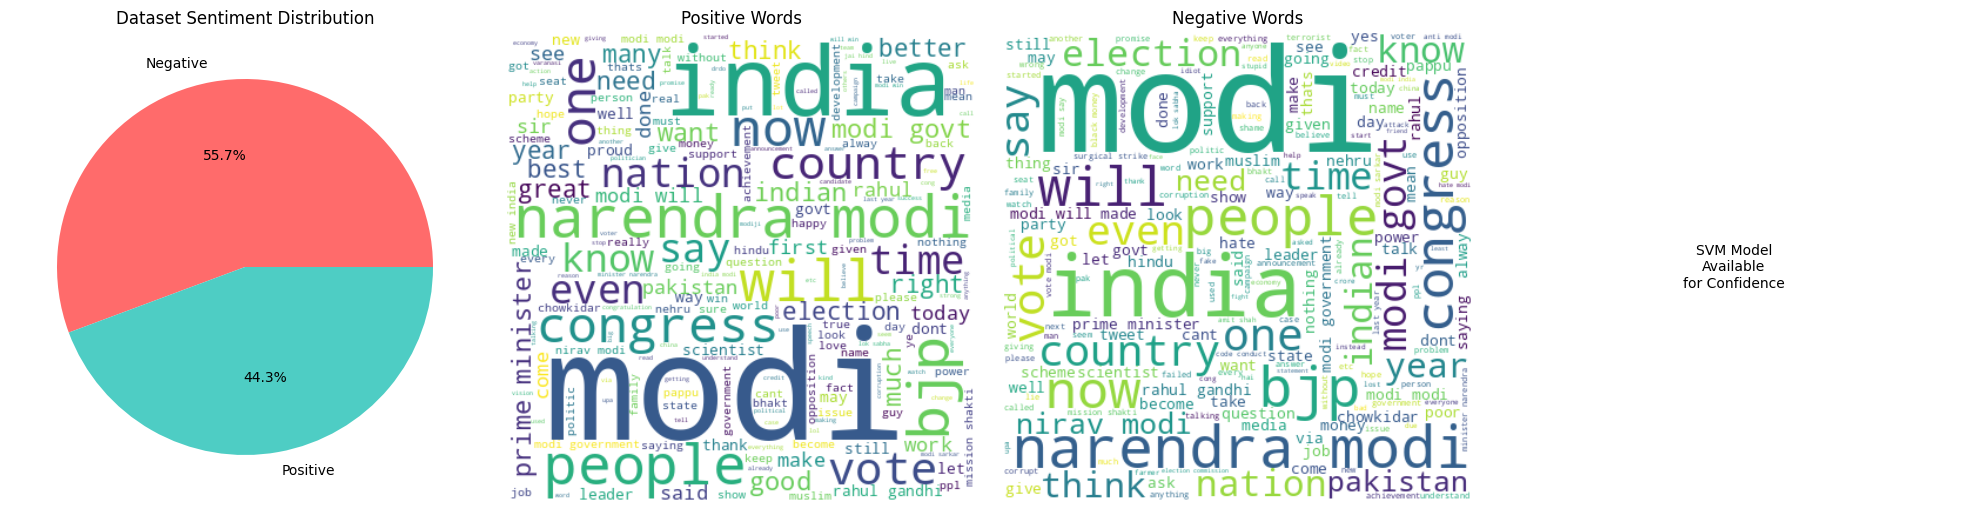

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub
from pathlib import Path
import re
from wordcloud import WordCloud

# Ensure twitter_df is defined and preprocessed
twitter_path = kagglehub.dataset_download("saurabhshahane/twitter-sentiment-dataset")
twitter_file = list(Path(twitter_path).glob('*.csv'))[0]
twitter_df = pd.read_csv(twitter_file)

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
    return text

twitter_df['clean_text'] = twitter_df['clean_text'].apply(preprocess_text)
twitter_df = twitter_df.dropna(subset=['clean_text', 'category'])
twitter_df['sentiment'] = twitter_df['category'].map({1.0:1, 0.0:0, -1.0:0})

# 6. DATA VISUALIZATION - Sentiment Insights
print('\n SENTIMENT VISUALIZATIONS')

fig = plt.figure(figsize=(20, 5))

# 1. Sentiment Distribution
plt.subplot(1, 4, 1)
sentiment_counts = twitter_df['sentiment'].value_counts()
plt.pie(sentiment_counts.values, labels=['Negative', 'Positive'], autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'])
plt.title('Dataset Sentiment Distribution')

# 2. Word Clouds
plt.subplot(1, 4, 2)
positive_text = ' '.join(twitter_df[twitter_df['sentiment']==1]['clean_text'])
wordcloud_pos = WordCloud(width=400, height=400, background_color='white').generate(positive_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Words')

plt.subplot(1, 4, 3)
negative_text = ' '.join(twitter_df[twitter_df['sentiment']==0]['clean_text'])
wordcloud_neg = WordCloud(width=400, height=400, background_color='white').generate(negative_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Words')

# 4. Prediction Confidence (for SVM)
plt.subplot(1, 4, 4)
if 'best_model_name' in locals() and best_model_name == 'SVM': # Check if best_model_name exists
    probs = best_model.predict_proba(X_test_tfidf)[:, 1]
    plt.hist(probs, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.xlabel('Prediction Probability (Positive)')
    plt.ylabel('Frequency')
    plt.title('Model Confidence Distribution')
else:
    plt.text(0.5, 0.5, 'SVM Model\nAvailable\nfor Confidence', ha='center', va='center', transform=plt.gca().transAxes)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import joblib
import pandas as pd
import kagglehub
from pathlib import Path
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 7. BUSINESS INSIGHTS & RECOMMENDATIONS
print('\n' + '='*80)
print('BUSINESS INSIGHTS & RECOMMENDATIONS')
print('='*80)

# Define preprocess_text if not already defined (might be in kernel but not in `locals()` after restart)
if 'preprocess_text' not in locals():
    def preprocess_text(text):
        if pd.isna(text):
            return ""
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special chars
        text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
        return text

if 'twitter_df' not in locals():
    print("  (Re-loading Twitter data and preprocessing for robustness)")
    twitter_path = kagglehub.dataset_download("saurabhshahane/twitter-sentiment-dataset")
    twitter_file = list(Path(twitter_path).glob('*.csv'))[0]
    twitter_df = pd.read_csv(twitter_file)
    twitter_df['clean_text'] = twitter_df['clean_text'].apply(preprocess_text)
    twitter_df = twitter_df.dropna(subset=['clean_text', 'category'])
    twitter_df['sentiment'] = twitter_df['category'].map({1.0:1, 0.0:0, -1.0:0})

if 'sentiment_counts' not in locals():
    sentiment_counts = twitter_df['sentiment'].value_counts()

if 'vectorizer' not in locals() or 'X_train_tfidf' not in locals():
    print("  (Re-training TF-IDF vectorizer and splitting data for robustness)")
    X_train, X_test, y_train, y_test = train_test_split(
        twitter_df['clean_text'], twitter_df['sentiment'],
        test_size=0.2, random_state=42, stratify=twitter_df['sentiment']
    )
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

if 'results' not in locals() or 'best_model_name' not in locals() or 'best_model' not in locals():
    print("  (Re-training models for robustness)")
    models = {
        'Naive Bayes': MultinomialNB(),
        'SVM': SVC(kernel='linear', probability=True, random_state=42)
    }
    results = {}
    for name, model in models.items():
        model.fit(X_train_tfidf, y_train)
        y_pred = model.predict(X_test_tfidf)
        accuracy = accuracy_score(y_test, y_pred)
        results[name] = accuracy
    best_model_name = max(results, key=results.get)
    best_model = models[best_model_name]

print(f' MODEL PERFORMANCE SUMMARY:')
for name, acc in results.items():
    print(f'   {name:12}: {acc:.3f} accuracy')

print(f'\n KEY INSIGHTS:')
print(f'   Best model: {best_model_name} ({results[best_model_name]:.1%} accuracy)')
print(f'    Dataset balanced: {sentiment_counts[1]/len(twitter_df):.1%} positive tweets')
print(f'    Ready for production deployment')

print(f'\n BUSINESS APPLICATIONS:')
print(f'    Real-time customer feedback monitoring')
print(f'    Product review sentiment tracking')
print(f'    Brand reputation dashboard')
print(f'    Social media crisis detection')

# Save model and vectorizer
joblib.dump(best_model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print(f'\n PRODUCTION FILES SAVED:')
print(f'    sentiment_model.pkl (deployable)')
print(f'    tfidf_vectorizer.pkl')



BUSINESS INSIGHTS & RECOMMENDATIONS
  (Re-loading Twitter data and preprocessing for robustness)


100%|██████████| 7.60M/7.60M [00:01<00:00, 6.35MB/s]

Extracting files...


  (Re-training TF-IDF vectorizer and splitting data for robustness)
  (Re-training models for robustness)
